In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import colorsys
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde, mannwhitneyu, kruskal
from matplotlib.gridspec import GridSpec
from matplotlib.colors import to_hex
from PIL import ImageColor

CONDITION_COLORS = {"static": "red", "flow": "dodgerblue", "high_flow": "mediumblue", "low_flow": "lightblue", "resevoir": "darkorange"}

def create_n_valued_palette(base_colour, n=5):
    """Create n shades of a base colour (name or hex) for per-image lines."""
    r, g, b = ImageColor.getcolor(base_colour, "RGB")
    r, g, b = r / 255, g / 255, b / 255
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    adjustments = np.linspace(0.5, 1.4, n)
    palette = []
    for a in adjustments:
        l_adj = min(max(l * a, 0), 1)
        rgb = colorsys.hls_to_rgb(h, l_adj, s)
        palette.append(to_hex(rgb))
    return palette

In [35]:
# def plot_timing_breakdown(timing_outputs_csv):
#     mean_timings = timing_outputs_csv.mean(numeric_only=True).drop(["image_index", "t_job_wall_s", "t_pipeline_s", 'Unnamed: 0'])
#     fig, ax = plt.subplots()
#     ax.pie(mean_timings, labels = mean_timings.index, colors = ["red", "darkorange", "limegreen", "dodgerblue", "darkviolet"])
#     plt.savefig("timing_breakdown_initial.pdf")
#     plt.savefig("timing_breakdown_initial.png")
    
# plot_timing_breakdown(pd.read_csv("first_attempt_time_check.csv"))



In [2]:
def combine_outputs(root_dir):
    csv_files = list(root_dir.rglob("*.csv"))
    if not csv_files:
        print("No CSV files found.")
        return None, None
    else:
        combined_analysis_metrics = []
        combined_branch_metrics = []
        for f in csv_files:
            try:
                df = pd.read_csv(f)
                df["source_file"] = str(f)
                df["source_folder"] = str(f.parent)
                if "analysis" in str(f):
                    combined_analysis_metrics.append(df)
                elif "branch" in str(f):
                    combined_branch_metrics.append(df)
                else:
                    print(f"Found extra uncategorised csv {f}")
            except Exception as e:
                print(f"Failed to read {f}: {e}")               

        if combined_analysis_metrics:
            combined_analysis_metrics = pd.concat(combined_analysis_metrics, ignore_index=True, sort=False)
            output_file = root_dir / "combined_analysis_metrics.csv"
            combined_analysis_metrics.to_csv(output_file, index=False)
        else:
            print("No analysis metric files could be read successfully.")
            combined_analysis_metrics = None
        if combined_branch_metrics:
            combined_branch_metrics = pd.concat(combined_branch_metrics, ignore_index=True, sort=False)
            output_file = root_dir / "combined_branch_metrics.csv"
            combined_branch_metrics.to_csv(output_file, index=False)
        else:
            print("No branch metric files could be read successfully.")
            combined_branch_metrics = None
        print(f"Total files combined: {len(combined_analysis_metrics)} analysis files and {len(combined_branch_metrics)} branch files")

        return combined_analysis_metrics, combined_branch_metrics

############################# UPDATE THIS FOR YOUR EXPERIMENT #####################
def find_condition(row, experiment_setup="old"):
    name = str(row["image_name"]).lower()
    if "static" in name:
        return "static"
    elif "resevoir" in name or "reservoir" in name:
        return "resevoir"
    elif experiment_setup == "old":
        if "flow" in name:
            return "flow"
        else:
            return "NA"
    else:
        if any(f"valve {n}" in name for n in [1, 2, 7, 8]):
            return "high_flow"
        elif any(f"valve {n}" in name for n in [3, 4, 5, 6]):
            return "low_flow"
        else:
            return "NA"


def plot_experiment_comparisons(df, y_metrics, xorder, plot_title, save_dir, save_type = "png"):
    fig, ax = plt.subplots(ncols = len(y_metrics), figsize=(4*len(y_metrics),5))
    for i, metric in enumerate(y_metrics):
        print(i, metric)
        sns.stripplot(data = df, x = "experiment", y = metric, ax = ax[i], zorder = 100,
                      hue = "experiment", palette = CONDITION_COLORS, order = xorder, legend = False)
        sns.boxplot(data = df, x = "experiment", y = metric, ax = ax[i], fill = False, color = "#000000", order = xorder)
    plt.tight_layout()
    out_path = Path(save_dir) / f"{plot_title}.{save_type}"
    print(out_path)
    plt.savefig(out_path)
    
    

In [3]:
def plot_orientation_kde(branch_df, conditions=None, save_dir=None):
    """Two-panel KDE of branch orientation: left weighted by length, right by volume.

    Automatically detects conditions from CONDITION_COLORS present in the data,
    so works for both old (static/flow) and new (static/high_flow/low_flow/resevoir) setups.

    Parameters
    ----------
    branch_df : DataFrame with columns experiment, image_name,
                orientation_to_device_axis_deg, path_length_um, branch_volume_um3
    conditions : list of condition names to plot (default: auto-detect from data)
    """
    if conditions is None:
        conditions = [c for c in CONDITION_COLORS if c in branch_df["experiment"].unique()]

    # Build per-image colour shades from CONDITION_COLORS
    img_colors = {}
    for condition in conditions:
        images = sorted(branch_df[branch_df["experiment"] == condition]["image_name"].unique())
        shades = create_n_valued_palette(CONDITION_COLORS[condition], max(len(images), 2))
        for i, img_name in enumerate(images):
            img_colors[img_name] = shades[i % len(shades)]

    weight_configs = [
        ("path_length_um",    "Proportional vessel length (a.u.)", "Branch orientation weighted by length"),
        ("branch_volume_um3", "Proportional vessel volume (a.u.)", "Branch orientation weighted by volume"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

    for ax, (weight_col, ylabel, title) in zip(axes, weight_configs):
        sub = branch_df.dropna(subset=["orientation_to_device_axis_deg", weight_col]).copy()
        sub = sub[sub["experiment"].isin(conditions)]

        x_eval = np.linspace(sub["orientation_to_device_axis_deg"].min(),
                             sub["orientation_to_device_axis_deg"].max(), 500)

        condition_kdes = {c: [] for c in conditions}

        for condition in conditions:
            images = sorted(sub[sub["experiment"] == condition]["image_name"].unique())
            for img_name in images:
                img_sub = sub[sub["image_name"] == img_name]
                angles = img_sub["orientation_to_device_axis_deg"].values
                weights_raw = img_sub[weight_col].values
                if len(angles) < 2 or weights_raw.sum() == 0:
                    continue
                weights = weights_raw / weights_raw.sum()
                kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
                y = kde(x_eval)
                y = y / y.sum()
                ax.plot(x_eval, y, color=img_colors.get(img_name, "gray"), alpha=0.35, linewidth=1)
                condition_kdes[condition].append(y)

        # Mean curves
        for condition in conditions:
            if condition_kdes[condition]:
                mean_y = np.mean(condition_kdes[condition], axis=0)
                n = len(condition_kdes[condition])
                ax.plot(x_eval, mean_y, color=CONDITION_COLORS[condition], linewidth=2.5,
                        label=f"Mean {condition.capitalize()}  (n={n})")

        ax.set_xlabel("Orientation to device axis (°)", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(title, fontsize=13)
        ax.legend(fontsize=11)
        sns.despine(ax=ax)

    if save_dir is not None:

        fig.savefig(Path(save_dir) / "orientation_kde.png", dpi=150)    
    plt.show()

In [4]:
def pca_plots(combined_analysis_metrics, save_dir=None):
    """PCA scatter, volcano/importance-significance plot, and significant-features bar chart.

    Uses PCA loadings (weighted by explained variance) for feature importance,
    and Mann-Whitney U / Kruskal-Wallis for statistical significance.
    Works for both 2-class and multiclass setups automatically.
    Returns only statistically significant features (p < 0.05).
    """
    X = combined_analysis_metrics.drop(
        ["experiment", "image_name", "source_file", "image_index",
         "chip_volume_um3", "convex_hull_volume_um3", "vessel_volume_um3", "source_folder"],
        axis=1
    )
    y = combined_analysis_metrics["experiment"]
    conditions = [c for c in CONDITION_COLORS if c in y.unique()]
    is_binary = len(conditions) == 2

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # --- Feature importance from PCA loadings (weighted by explained variance) ---
    loadings = pca.components_  # (2, n_features)
    ev = pca.explained_variance_ratio_  # (2,)

    if is_binary:
        # Signed importance: variance-weighted sum of loadings across PCs
        importance_raw = loadings[0] * ev[0] + loadings[1] * ev[1]
        # Orient so positive direction = class with higher mean PC1 score
        mean_pc1 = {c: X_pca[y.values == c, 0].mean() for c in conditions}
        pos_class = max(mean_pc1, key=mean_pc1.get)
        neg_class = min(mean_pc1, key=mean_pc1.get)
        feat_imp = pd.Series(importance_raw, index=X.columns).sort_values(key=abs, ascending=False)
    else:
        # Multiclass: magnitude of variance-weighted loading vector
        weighted_loadings = loadings * ev[:, None]  # (2, n_features)
        importance_raw = np.sqrt((weighted_loadings ** 2).sum(axis=0))
        feat_imp = pd.Series(importance_raw, index=X.columns).sort_values(ascending=False)
        # Dominant class: which class has the most extreme mean for each feature
        group_means = pd.DataFrame({c: X.loc[y == c].mean() for c in conditions})
        overall_mean = X.mean()
        deviations = group_means.subtract(overall_mean, axis=0).abs()
        dominant_class = deviations.idxmax(axis=1)

    # --- Statistical significance ---
    p_values = []
    if is_binary:
        for col in X.columns:
            groups = [X.loc[y == c, col] for c in conditions]
            _, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            p_values.append(p)
    else:
        for col in X.columns:
            groups = [X.loc[y == c, col].values for c in conditions]
            _, p = kruskal(*groups)
            p_values.append(p)

    p_values = np.array(p_values)
    neg_log_p = -np.log10(np.clip(p_values, 1e-300, None))
    sig_threshold = -np.log10(0.05)
    importance = feat_imp.reindex(X.columns).values

    # Significant features mask and series
    sig_mask_all = p_values < 0.05
    sig_features = feat_imp[sig_mask_all[feat_imp.index.map(lambda f: list(X.columns).index(f))]]

    # --- Layout ---
    fig = plt.figure(figsize=(20, 6), constrained_layout=True)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 1.4])
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])

    # --- 1. PCA scatter ---
    for name in conditions:
        mask = y == name
        ax0.scatter(
            X_pca[mask.values, 0], X_pca[mask.values, 1],
            c=CONDITION_COLORS[name], label=name.capitalize(),
            s=80, edgecolors="k", linewidths=0.4, alpha=0.8
        )
    ax0.set_xlabel(f"PC1 ({ev[0]:.1%} var.)")
    ax0.set_ylabel(f"PC2 ({ev[1]:.1%} var.)")
    ax0.set_title("PCA – first two components")
    ax0.legend()

    # --- 2. Importance vs significance ---
    if is_binary:
        sig_pos = (neg_log_p >= sig_threshold) & (importance > 0)
        sig_neg = (neg_log_p >= sig_threshold) & (importance < 0)
        not_sig = neg_log_p < sig_threshold

        ax1.scatter(importance[not_sig], neg_log_p[not_sig], c="grey", alpha=0.5, s=40, label="Not significant")
        ax1.scatter(importance[sig_pos], neg_log_p[sig_pos], c=CONDITION_COLORS[pos_class],
                    alpha=0.8, s=60, label=f"Significant → {pos_class}")
        ax1.scatter(importance[sig_neg], neg_log_p[sig_neg], c=CONDITION_COLORS[neg_class],
                    alpha=0.8, s=60, label=f"Significant → {neg_class}")
        ax1.axvline(0, color="grey", linewidth=0.5)
        ax1.set_xlabel(f"PCA loading importance (+ → {pos_class}, − → {neg_class})")
        ax1.set_title("Volcano plot – PCA loading vs significance")
    else:
        sig_mask = neg_log_p >= sig_threshold
        ax1.scatter(importance[~sig_mask], neg_log_p[~sig_mask], c="grey", alpha=0.5, s=40, label="Not significant")
        for name in conditions:
            cls_mask = sig_mask & (dominant_class.reindex(X.columns) == name).values
            if cls_mask.any():
                ax1.scatter(importance[cls_mask], neg_log_p[cls_mask], c=CONDITION_COLORS[name],
                            alpha=0.8, s=60, label=f"Sig. dominant → {name}")
        ax1.set_xlabel("PCA loading importance (variance-weighted magnitude)")
        ax1.set_title("Importance vs significance (Kruskal-Wallis)")

    ax1.axhline(sig_threshold, color="grey", linestyle="--", linewidth=0.8, label="p = 0.05")

    top_idx = np.argsort(neg_log_p * np.abs(importance))[-5:]
    for ti in top_idx:
        ax1.annotate(X.columns[ti], (importance[ti], neg_log_p[ti]),
                     fontsize=7, ha="center", va="bottom",
                     textcoords="offset points", xytext=(0, 5))

    ax1.set_ylabel("$-\\log_{10}$(p-value)")
    ax1.legend(fontsize=8)

    # --- 3. Top feature importances bar chart ---
    top = feat_imp.head(10)
    if is_binary:
        colors = [CONDITION_COLORS[pos_class] if v > 0 else CONDITION_COLORS[neg_class] for v in top]
        ax2.set_xlabel(f"Loading importance (+ → {pos_class}, − → {neg_class})")
    else:
        colors = [CONDITION_COLORS.get(dominant_class[feat], "grey") for feat in top.index]
        ax2.set_xlabel("Loading importance (coloured by dominant class)")

    ax2.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax2.set_title("Top 10 discriminating features")
    ax2.axvline(0, color="grey", linewidth=0.8)
    ax2.tick_params(axis="y", labelsize=9)

    if save_dir is not None:
        fig.savefig(Path(save_dir) / "pca_plots.png", dpi=150)
    plt.show()


    print(f"Significant features: {len(sig_features)} / {len(X.columns)}")    
    return sig_features.index.to_list()

In [5]:
root_dir = Path(r"Z:\Bel\Dorota_Vascumap") 
output_dir = root_dir.parent / f"{root_dir.name}_output_data"
output_dir.mkdir(parents=True, exist_ok=True)

# experiment_setup = "new" ###########update to "old" if you only have two conditions (flow/static)
# if experiment_setup == "old":
#     xorder = ["static", "flow"]
# else:
#     xorder = ["static", "resevoir", "low_flow", "high_flow"]
combined_analysis_metrics, combined_branch_metrics = combine_outputs(root_dir)
# combined_analysis_metrics["experiment"] = combined_analysis_metrics.apply(find_condition, axis=1, experiment_setup = experiment_setup)
# combined_branch_metrics["experiment"] = combined_branch_metrics.apply(find_condition, axis=1, experiment_setup = experiment_setup)

# filenames_to_remove = ["test_1", "test_2"] #############udpate this with your filenames

# combined_analysis_metrics = combined_analysis_metrics[~combined_analysis_metrics["image_name"].isin(filenames_to_remove)]
# combined_branch_metrics = combined_branch_metrics[~combined_branch_metrics["image_name"].isin(filenames_to_remove)]

combined_analysis_metrics.to_csv(output_dir / "dorota_combined_analysis_metrics.csv")
combined_branch_metrics.to_csv(output_dir / "dorota_combined_branch_metrics.csv")

Total files combined: 16 analysis files and 21519 branch files


In [ ]:
combined_analysis_metrics_minimal = combined_analysis_metrics.drop(columns=["median_sprout_and_branch_median_cs_area_um2",
                                       "median_internal_pore_area_um2",
                                       "median_internal_pore_max_inscribed_radius_um", 
                                       "p90_minus_p10_internal_pore_area_um2",
                                       "total_internal_pore_count", 
                                       "p90_minus_p10_internal_pore_max_inscribed_radius_um",
                                       "internal_pore_area_fraction_in_filled_vascular_area"], inplace=False)

In [69]:
combined_analysis_metrics_minimal[["image_name", "experiment"]]

,image_name,experiment
0,17.03.26 flow high vs low 6million day 7_img0_...,high_flow
1,17.03.26 flow high vs low 6million day 7_img1_...,high_flow
2,17.03.26 flow high vs low 6million day 7_img2_...,high_flow
3,17.03.26 reservoirs 6million day 7_img0_Reserv...,resevoir
4,17.03.26 reservoirs 6million day 7_img1_Reserv...,resevoir
...,...,...
83,18.02.26 static 6million day 7_img3_Static 8,static
84,19.03.26 flow high vs low 6million day 9(7)_im...,high_flow
85,19.03.26 flow high vs low 6million day 9(7)_im...,low_flow
86,19.03.26 flow high vs low 6million day 9(7)_im...,low_flow


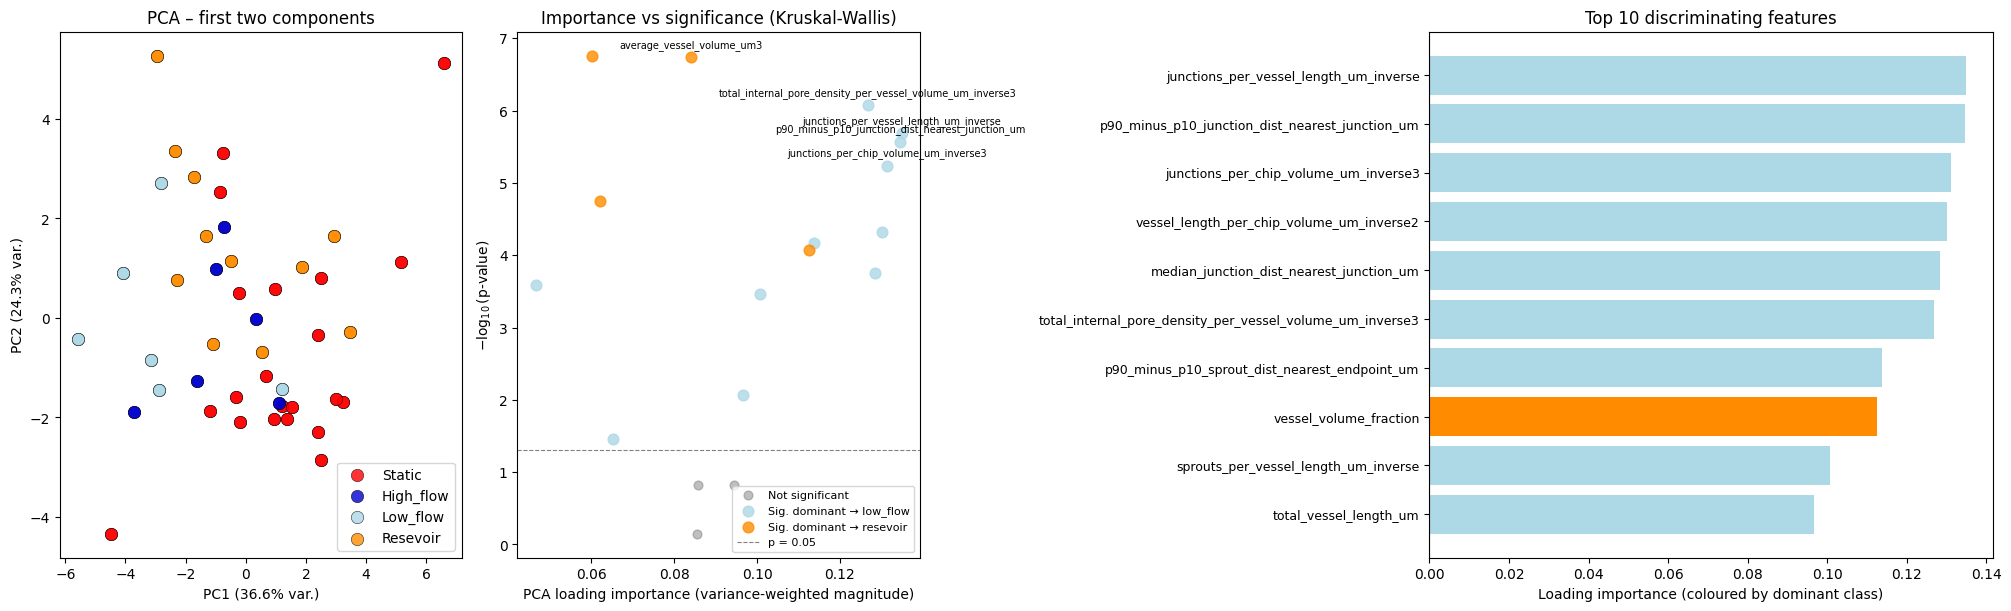

Significant features: 15 / 18


In [65]:
significant_params = pca_plots(combined_analysis_metrics_minimal, save_dir=output_dir)


0 junctions_per_vessel_length_um_inverse
1 p90_minus_p10_junction_dist_nearest_junction_um
2 junctions_per_chip_volume_um_inverse3
3 vessel_length_per_chip_volume_um_inverse2
4 median_junction_dist_nearest_junction_um
Z:\Bel\Farid_bel\New_Experiment_Outputs_output_data\significant_changes.png


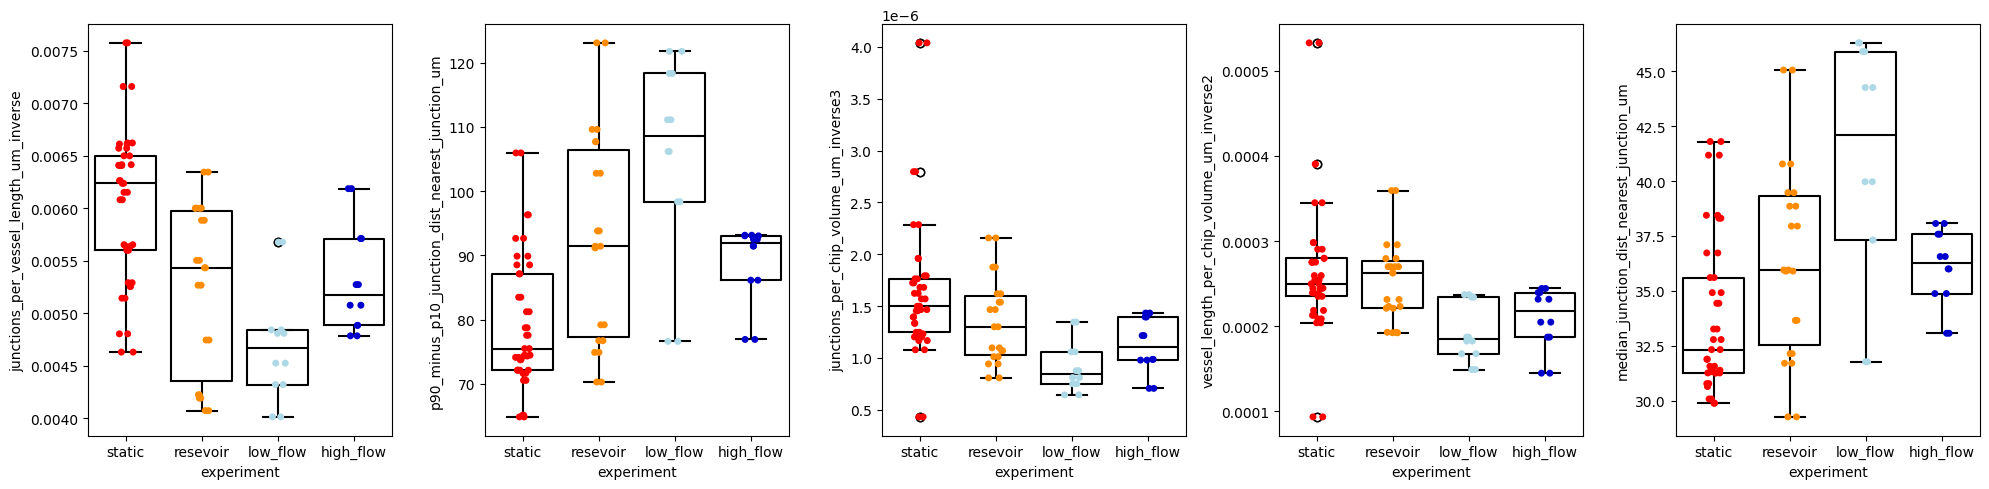

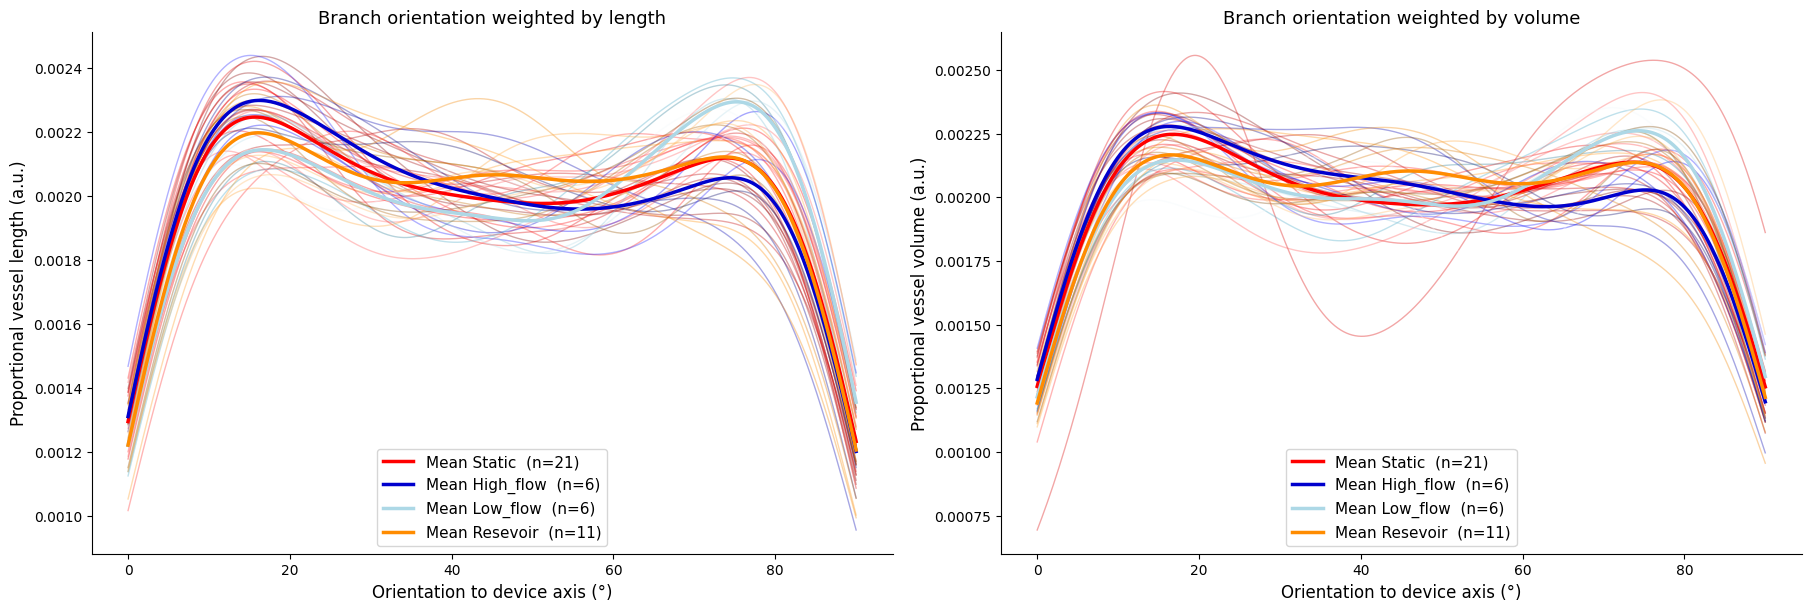

In [66]:
plot_experiment_comparisons(combined_analysis_metrics_minimal, significant_params[:5], xorder, "significant_changes", output_dir)
plot_orientation_kde(combined_branch_metrics, save_dir=output_dir)